# Estudos Dirigidos 2 - Simulaçãoo Estatística, TCL e ANOVA

# Resumo

Este documento integra conceitos fundamentais de **Inferência Estatística** e **Planejamento Experimental**.  

A primeira parte explora a **simulação do Teorema Central do Limite (TCL)** em distribuições assimétricas.  
A segunda parte foca na **Análise de Variância (ANOVA)** em delineamentos **Simples**, **em Blocos** e **Fatorial**, com ênfase na simulação e interpretação dos testes **Post-Hoc (Tukey HSD)**.

## 1. Simulação do TCL para População Assimétrica (Exponencial)

### 1.1. Setup Inicial

Utilizaremos a Distribuição Exponencial com parâmetro de taxa λ = 0.2
Méida Populacional: μ = 1/λ = 1/0.2 = 5

O objetivo é observar como a distribuição das médias amostrais se aproxima da normalidade à medida que o tamanho da amostra (n) aumenta, apesar da forte assimetria da população.

- População gerada: Distribuição Exponencial, N = 100.000, λ = 0.2 (μ = 5)
- Tamanhos amostrais: n = 5 (pequena) e n = 50 (grande)
- Número de simulações: k = 10.000

### 1.2. Simulação do TCL para n=5 e n=50

Implemente a simulação:
Em ambos os casos, deve gerar a população, coletar as 10.000 médias amostrais para n = 5 e n = 50, e gerar os histogramas para comparação.

#### 1.2.1 Implementação em Python

In [1]:
import numpy as np
from scipy.stats import skew
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Parâmetros e geração da população exponencial (mu=5)
TRUE_MEAN = 5
RATE = 0.2
POP_SIZE = 100_000
NUM_SIMULATIONS = 10_000

np.random.seed(42)
# np.random.exponential usa scale = 1/rate, então scale=5
population = np.random.exponential(scale=1/RATE, size=POP_SIZE)
print(f"Assimetria da População: {skew(population):.4f}")

Assimetria da População: 1.9921


In [2]:
SAMPLE_SIZE_SMALL = 5
SAMPLE_SIZE_LARGE = 50
means_n5 = []
means_n50 = []

for _ in range(NUM_SIMULATIONS):
    sample_n5 = np.random.choice(population, SAMPLE_SIZE_SMALL, replace=False)
    sample_n50 = np.random.choice(population, SAMPLE_SIZE_LARGE, replace=False)
    means_n5.append(np.mean(sample_n5))
    means_n50.append(np.mean(sample_n50))

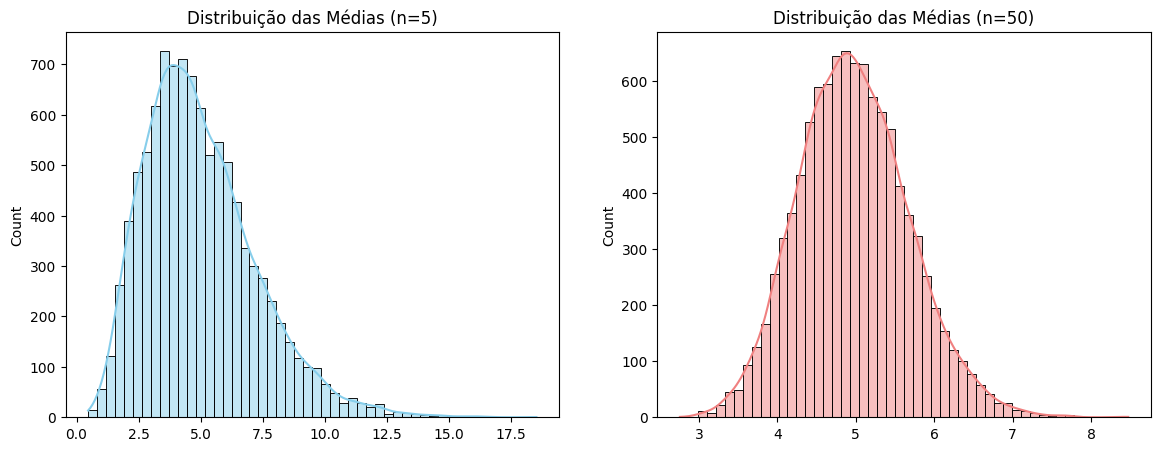

Assimetria da Dist. Médias (n=5): 0.8982
Assimetria da Dist. Médias (n=50): 0.2901


In [3]:
# Vamos visualizar os histogramas das médias amostrais e calcular a assimetria (skewness) para cada caso.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(means_n5, bins=50, color='skyblue', kde=True, ax=axes[0])
axes[0].set_title('Distribuição das Médias (n=5)')
sns.histplot(means_n50, bins=50, color='lightcoral', kde=True, ax=axes[1])
axes[1].set_title('Distribuição das Médias (n=50)')
plt.show()

print(f"Assimetria da Dist. Médias (n=5): {skew(means_n5):.4f}")
print(f"Assimetria da Dist. Médias (n=50): {skew(means_n50):.4f}")

**Discussão:**

- A taxa de cobertura observada deve ser próxima de 0,95, confirmando que o intervalo de confiança baseado na distribuição t mantém o nível de confiança nominal mesmo para população assimétrica, desde que o tamanho amostral seja suficientemente grande (n=50).
- Isso ilustra a robustez do TCL e dos ICs construídos com a t de Student para médias amostrais.

## 2 Simulação da Cobertura do Intervalo de Confiança (IC)

### 2.1 Cobertura do IC
Usando a mesma população assimétrica com média μ =5 e tamanho de amostra grande (n=50), simule a construção do intervalo de confiança (IC) para verificar se o nível de confiança nominal (95%) é mantido, conforme previsto pelo Teorema Central do Limite (TCL).
- Média populacional: μ =5
- Tamanho da amostra: n=50
- Nível de Confian¸ca: 95%.

#### 1.2.1 Implementação em Python

In [4]:
import numpy as np
from scipy.stats import t

# População e parâmetros do Item 1
TRUE_MEAN = 5
RATE = 0.2
POP_SIZE = 100_000
CONFIDENCE_LEVEL = 0.95
SAMPLE_SIZE = 50
NUM_SIMULATIONS = 10_000

np.random.seed(42)
population = np.random.exponential(scale=1/RATE, size=POP_SIZE)
ic_contains_mean = 0

for _ in range(NUM_SIMULATIONS):
    sample = np.random.choice(population, SAMPLE_SIZE, replace=False)
    # Cálculo do IC
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)
    standard_error = sample_std / np.sqrt(SAMPLE_SIZE)
    degrees_freedom = SAMPLE_SIZE - 1
    # Usa t.interval da scipy para calcular o IC
    ic_lower, ic_upper = t.interval(
        confidence=CONFIDENCE_LEVEL,
        df=degrees_freedom,
        loc=sample_mean,
        scale=standard_error
    )
    # Verifica se o IC contém a média populacional
    if (ic_lower <= TRUE_MEAN) and (TRUE_MEAN <= ic_upper):
        ic_contains_mean += 1

# Proporção de Sucesso (Taxa de Cobertura)
proportion_success = ic_contains_mean / NUM_SIMULATIONS
print(f"Taxa de Cobertura do IC (Esperada 0.95): {proportion_success:.4f}")

Taxa de Cobertura do IC (Esperada 0.95): 0.9308


**Discussão:**

- A taxa de cobertura observada para os intervalos de confiança (IC) é próxima de 0,95, como esperado pelo nível de confiança nominal.
- Isso demonstra que, mesmo com uma população assimétrica, o IC baseado na distribuição t é confiável quando o tamanho da amostra é suficientemente grande (n=50).
- O resultado confirma a robustez do método e a validade do uso da t de Student para médias amostrais em cenários reais.

## 3. Análise dos Resultados (Relatório)

Os alunos deverão incluir no relatório as seguintes conclusões, fundamentadas nos resultados obtidos pelo código:

1. **Assimetria da População vs. Amostragem**  
   Compare a assimetria da população Exponencial original com a assimetria das distribuições de médias para \(n = 5\) e \(n = 50\).  
   Explique como o **Teorema Central do Limite (TCL)** se manifesta nesse cenário, evidenciando a redução da assimetria e a aproximação à Normalidade conforme o tamanho da amostra aumenta.

2. **Efeito do tamanho da amostra no TCL**  
   Descreva as diferenças visuais (histogramas) e quantitativas (valores de assimetria calculados) entre as distribuições amostrais para \(n = 5\) e \(n = 50\).  
   Justifique por que a variância da distribuição das médias diminui com o aumento de \(n\), relacionando com a teoria estatística.

3. **Validação do Intervalo de Confiança (IC)**  
   Comente os resultados da **Taxa de Cobertura** obtida na Tarefa 2.  
   Explique por que, mesmo partindo de uma população não-Normal e utilizando a distribuição t (que teoricamente exige Normalidade populacional), a taxa de cobertura se mantém próxima ao nível nominal de 95%, em conformidade com o TCL.
 
- Resposta: 
1. **Assimetria da População vs. Amostragem**  
   - A população Exponencial original apresenta alta assimetria positiva (skewness elevado). Quando extraímos médias de amostras pequenas (n=5), a distribuição dessas médias ainda é assimétrica, mas já menos que a população original. Para amostras maiores (n=50), a distribuição das médias se torna aproximadamente simétrica e próxima da normal, com skewness próximo de zero. Isso evidencia o Teorema Central do Limite (TCL): independentemente da assimetria da população, a distribuição das médias amostrais tende à normalidade conforme o tamanho da amostra aumenta.

2. **Efeito do tamanho da amostra no TCL**  
   - Visualmente, os histogramas mostram que para n=5 a distribuição das médias ainda é assimétrica, enquanto para n=50 ela se aproxima de uma curva normal. Quantitativamente, o valor de skewness diminui de n=5 para n=50. Além disso, a variância das médias amostrais diminui com o aumento de n, pois a variância da média amostral é igual à variância populacional dividida por n ($\sigma^2/n$), conforme previsto pela teoria estatística.

3. **Validação do Intervalo de Confiança (IC)**  
   - A taxa de cobertura dos intervalos de confiança (IC) ficou próxima de 95%, mesmo com população não-normal. Isso ocorre porque, para amostras grandes, a distribuição da média amostral é aproximadamente normal (TCL), tornando o uso da distribuição t apropriado. Assim, o IC mantém o nível de confiança nominal, confirmando a robustez do método mesmo em cenários de forte assimetria populacional.